In [1]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

C:\Users\zaine\AppData\Local\Temp\ipykernel_12592\3060170301.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


True

In [2]:
docs = (
    PyPDFLoader("./documents/DSwithBappy_Company_Policies.pdf").load()
    + PyPDFLoader("./documents/DSwithBappy_Company_Profile.pdf").load()
    + PyPDFLoader("./documents/DSwithBappy_Product_and_Pricing.pdf").load()
)

In [3]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [4]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

In [5]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [6]:
# --------------------------------------------------
# Graph State
# --------------------------------------------------
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]
    relevant_docs: List[Document]     # New

    answer: str

In [7]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


# IMPORTANT: no `.content` for structured output
should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: "State"):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

In [8]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }


In [9]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

In [11]:
# New

class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevance_llm = llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    
    relevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}



In [12]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

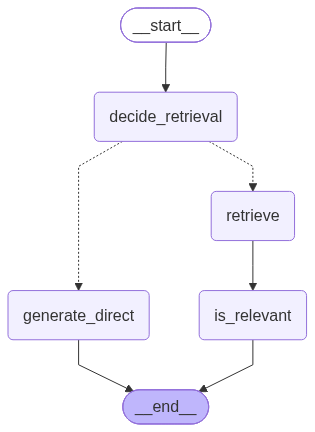

In [13]:
g = StateGraph(State)

# --------------------
# Nodes
# --------------------
g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)
g.add_node("is_relevant", is_relevant) # New

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("generate_direct", END)
g.add_edge("retrieve", "is_relevant") # New
g.add_edge("is_relevant", END) # New

app = g.compile()
app

In [14]:
result = app.invoke(
    {
        "question": "Who is the Founder of DSwithBappy",
        "need_retrieval": False,
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])

In [15]:
result['need_retrieval']

True

In [16]:
for doc in result['docs']:
    print(doc.page_content)
    print("*"*100)

Founder
Bappy founded DSwithBappy with the goal of making modern AI engineering easier to
understand through practical, step-by-step learning.
Through technical tutorials, courses, end-to-end projects, and community content, DSwithBappy
focuses on helping learners turn AI concepts into working applications.
Platform & Learning Team
DSwithBappy brings together content creation, AI engineering, course development, project
building, and learner support to create a practical learning experience.
●
 AI Engineering & Project Development
●
 Course and Curriculum Development
●
****************************************************************************************************
DSwithBappy - Company Profile
Company Overview
DSwithBappy is an AI education and engineering platform focused on helping learners build
practical, production-ready skills in artificial intelligence.
The platform specializes in hands-on learning across Generative AI, RAG, Agentic AI, LLM
applications, AI engineering, and 

In [17]:
for doc in result['relevant_docs']:
    print(doc.page_content)
    print("*"*100)

Founder
Bappy founded DSwithBappy with the goal of making modern AI engineering easier to
understand through practical, step-by-step learning.
Through technical tutorials, courses, end-to-end projects, and community content, DSwithBappy
focuses on helping learners turn AI concepts into working applications.
Platform & Learning Team
DSwithBappy brings together content creation, AI engineering, course development, project
building, and learner support to create a practical learning experience.
●
 AI Engineering & Project Development
●
 Course and Curriculum Development
●
****************************************************************************************************


In [18]:
result['relevant_docs']

[Document(id='db1399de-6a25-4603-968b-c0353612c7ac', metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-08-26T04:40:11+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-08-26T04:40:11+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': './documents/DSwithBappy_Company_Profile.pdf', 'total_pages': 2, 'page': 1, 'page_label': '2'}, page_content='Founder\nBappy founded DSwithBappy with the goal of making modern AI engineering easier to\nunderstand through practical, step-by-step learning.\nThrough technical tutorials, courses, end-to-end projects, and community content, DSwithBappy\nfocuses on helping learners turn AI concepts into working applications.\nPlatform & Learning Team\nDSwithBappy brings together content creation, AI engineering, course development, project\nbuilding, and learner support to create a practical learning experience.\n●\n AI Engineering & Project Deve